<a href="https://colab.research.google.com/github/carolineb3/Earnings-Call-NLP-Pipeline/blob/main/notebooks/05_finbert_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 5: FinBERT Sentiment Scoring

This notebook adds transformer-based sentiment features to the earnings call data using `ProsusAI/finbert`, a pretrained financial sentiment model from HuggingFace.

FinBERT is used here for inference only. We are not training a new transformer model. The goal is to score the prepared remarks and Q&A sections as positive, negative, and neutral, then add those scores to the pipeline as additional sentiment features.

One issue with earnings calls is length. Full transcript sections are much longer than FinBERT can process in one pass, so this notebook splits each section into token-length chunks, scores each chunk, and combines the chunk scores into one section-level result.

## What this notebook does

- Reads `584_earnings_sentiment.parquet` from Step 4.
- Loads the `ProsusAI/finbert` tokenizer and sequence classification model.
- Scores raw `prepared_remarks` and `qa_section` text separately.
- Splits long sections into chunks of 450 tokens or fewer.
- Adds `[CLS]` and `[SEP]` tokens to each chunk before scoring.
- Combines chunk-level probabilities using a token-count-weighted average.
- Saves the result as `584_earnings_finbert.parquet`.

## Output

- `584_earnings_finbert.parquet`

New columns added include:

- `prep_finbert_positive`
- `prep_finbert_negative`
- `prep_finbert_neutral`
- `prep_finbert_chunk_count`
- `qa_finbert_positive`
- `qa_finbert_negative`
- `qa_finbert_neutral`
- `qa_finbert_chunk_count`

## Notes

- A GPU runtime is strongly recommended. CPU inference works, but it is very slow for full-section chunked scoring across thousands of transcripts.
- FinBERT scores are based on raw transcript text, not the cleaned LDA text.
- The chunk-count columns are kept as diagnostics so we can see how much text each section required.

In [ ]:
# =============================================================================
# STEP 5 — FinBERT Sentiment Scoring
# Use ProsusAI/finbert to score prepared remarks and Q&A sections, then save
# the section-level sentiment features for the next notebook.
# =============================================================================

!pip install transformers torch accelerate pyspark -q

from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import shutil
import torch
import numpy as np
import pandas as pd

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
from pyspark.sql import SparkSession

# Give Spark more driver memory
os.environ['PYSPARK_SUBMIT_ARGS'] = '--driver-memory 8g pyspark-shell'

# Start a new Spark session for this notebook
_active = SparkSession.getActiveSession()
if _active is not None:
    _active.stop()

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR    = "/content/drive/MyDrive/MIS_584_Project"
PARQUET_IN  = f"{BASE_DIR}/Parquet/584_earnings_sentiment"
PARQUET_OUT = f"{BASE_DIR}/Parquet/584_earnings_finbert"

# Write local output first, then copy completed folder to Drive to avoid incomplete Spark commit folders
LOCAL_OUT = "/content/584_earnings_finbert"

print("PARQUET_IN :", PARQUET_IN)
print("PARQUET_OUT:", PARQUET_OUT)
print("LOCAL_OUT  :", LOCAL_OUT)

# ── Check the Step 4 checkpoint before loading the model ─────────────────────
print("\nChecking input checkpoint...")
print("Path exists:", os.path.exists(PARQUET_IN))

parquet_files = glob.glob(f"{PARQUET_IN}/**/*.parquet", recursive=True)
print("Parquet files found:", len(parquet_files))

if parquet_files:
    print("Example file:", parquet_files[0])
else:
    raise FileNotFoundError(
        f"No Parquet files found in {PARQUET_IN}. "
        "Rerun Step 4 LM sentiment before running FinBERT."
    )

# ── Start Spark and load data ────────────────────────────────────────────────
spark = SparkSession.builder \
    .master("local") \
    .appName("584_FinBERT") \
    .config("spark.driver.maxResultSize", "0") \
    .getOrCreate()

sc = spark.sparkContext
print(f"\nSpark version: {spark.version}")

# Read actual Parquet part files directly
df = spark.read.parquet(*parquet_files)
pdf = df.toPandas()

print(f"\nLoaded {len(pdf)} transcripts from sentiment checkpoint.")
print("Has prep_net_sentiment?", "prep_net_sentiment" in pdf.columns)
print("Has qa_net_sentiment?", "qa_net_sentiment" in pdf.columns)
print("Has prepared_remarks?", "prepared_remarks" in pdf.columns)
print("Has qa_section?", "qa_section" in pdf.columns)

required_cols = [
    "ticker",
    "quarter",
    "prepared_remarks",
    "qa_section",
    "prep_net_sentiment",
    "qa_net_sentiment",
    "pct_return_3d",
    "return_label"
]

missing_cols = [col for col in required_cols if col not in pdf.columns]

if missing_cols:
    raise ValueError(f"Missing required columns for FinBERT step: {missing_cols}")

print("\nInput checkpoint is valid. Proceeding to FinBERT scoring.")

# ── Load FinBERT ──────────────────────────────────────────────────────────────
print("\nLoading ProsusAI/finbert model...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(
    f"Using device: {device}  "
    f"{'(GPU — fast!)' if device.type == 'cuda' else '(CPU — very slow for full-section chunked scoring)'}"
)

tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
fb_model  = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

fb_model = fb_model.to(device)
fb_model.eval()

print("FinBERT label mapping:", fb_model.config.id2label)

# ProsusAI/finbert label order:
# index 0 = positive
# index 1 = negative
# index 2 = neutral

# ── Helper functions ─────────────────────────────────────────────────────────
def chunk_text_by_tokens(text, tokenizer, max_chunk_tokens=450):
    """
    Tokenize the full text without truncation and split token IDs into chunks
    that fit within FinBERT's 512-token limit.

    max_chunk_tokens=450 leaves room for [CLS] and [SEP] special tokens.
    """
    token_ids = tokenizer.encode(
        text,
        add_special_tokens=False,
        truncation=False
    )

    return [
        token_ids[i : i + max_chunk_tokens]
        for i in range(0, len(token_ids), max_chunk_tokens)
    ]


def score_finbert_chunks(
    text,
    tokenizer,
    model,
    device,
    max_chunk_tokens=450,
    batch_size=8
):
    """
    Score a full text section by chunking it into token-length segments,
    running each chunk through FinBERT, then computing a token-count-weighted
    average of the chunk-level probabilities.

    Returns:
        positive probability,
        negative probability,
        neutral probability,
        chunk count
    """
    if not text or not isinstance(text, str) or not text.strip():
        return 0.0, 0.0, 1.0, 0

    chunks = chunk_text_by_tokens(text, tokenizer, max_chunk_tokens)

    if not chunks:
        return 0.0, 0.0, 1.0, 0

    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    all_probs = []

    for i in range(0, len(chunks), batch_size):
        batch_chunks = chunks[i : i + batch_size]

        # Add [CLS] ... [SEP] special tokens manually
        encoded = [
            [tokenizer.cls_token_id] + chunk + [tokenizer.sep_token_id]
            for chunk in batch_chunks
        ]

        max_len = max(len(e) for e in encoded)

        input_ids = [
            e + [pad_id] * (max_len - len(e))
            for e in encoded
        ]

        attention_mask = [
            [1] * len(e) + [0] * (max_len - len(e))
            for e in encoded
        ]

        input_ids_t = torch.tensor(input_ids, device=device)
        attention_mask_t = torch.tensor(attention_mask, device=device)

        with torch.no_grad():
            logits = model(
                input_ids=input_ids_t,
                attention_mask=attention_mask_t
            ).logits

        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.extend(probs)

    arr = np.array(all_probs)

    weights = np.array([len(c) for c in chunks], dtype=float)
    weights = weights / weights.sum()

    weighted = (arr * weights[:, None]).sum(axis=0)

    # Clear unused GPU cache between calls
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return (
        round(float(weighted[0]), 6),   # positive
        round(float(weighted[1]), 6),   # negative
        round(float(weighted[2]), 6),   # neutral
        len(chunks)
    )

# ── Score prepared remarks ───────────────────────────────────────────────────
print(f"\nScoring {len(pdf)} transcripts with FinBERT...")

print("\n--- Prepared Remarks: chunked full-section scoring ---")

prep_results = []

for text in tqdm(pdf["prepared_remarks"].tolist(), desc="FinBERT prep"):
    pos, neg, neu, n = score_finbert_chunks(
        text,
        tokenizer,
        fb_model,
        device
    )

    prep_results.append({
        "finbert_positive": pos,
        "finbert_negative": neg,
        "finbert_neutral":  neu,
        "finbert_chunk_count": n
    })

# ── Score Q&A sections ───────────────────────────────────────────────────────
print("\n--- Q&A Sections: chunked full-section scoring ---")

qa_results = []

for text in tqdm(pdf["qa_section"].tolist(), desc="FinBERT Q&A"):
    pos, neg, neu, n = score_finbert_chunks(
        text,
        tokenizer,
        fb_model,
        device
    )

    qa_results.append({
        "finbert_positive": pos,
        "finbert_negative": neg,
        "finbert_neutral":  neu,
        "finbert_chunk_count": n
    })

# ── Merge FinBERT results back into dataset ──────────────────────────────────
prep_fb_df = pd.DataFrame(prep_results).add_prefix("prep_")
qa_fb_df   = pd.DataFrame(qa_results).add_prefix("qa_")

pdf = pd.concat([pdf, prep_fb_df, qa_fb_df], axis=1)

# Downstream column names created:
# prep_finbert_positive
# prep_finbert_negative
# prep_finbert_neutral
# prep_finbert_chunk_count
# qa_finbert_positive
# qa_finbert_negative
# qa_finbert_neutral
# qa_finbert_chunk_count

# ── Chunk-count diagnostics ──────────────────────────────────────────────────
print(f"\n{'='*55}")
print("  FinBERT Chunk Statistics")
print(f"{'='*55}")

print(
    f"  Prepared remarks — avg chunks: {pdf['prep_finbert_chunk_count'].mean():.1f}  "
    f"max: {pdf['prep_finbert_chunk_count'].max()}"
)

print(
    f"  Q&A sections     — avg chunks: {pdf['qa_finbert_chunk_count'].mean():.1f}  "
    f"max: {pdf['qa_finbert_chunk_count'].max()}"
)

print(
    f"  Single-chunk docs (prep): "
    f"{(pdf['prep_finbert_chunk_count'] == 1).sum()}"
)

print(
    f"  Single-chunk docs (Q&A) : "
    f"{(pdf['qa_finbert_chunk_count'] == 1).sum()}"
)

# ── Diagnostic: FinBERT vs LM dictionary agreement ───────────────────────────
print(f"\n{'='*80}")
print("  FinBERT vs LM Net Sentiment Comparison")
print(f"{'='*80}")

print(
    f"  {'Ticker':<8} {'Quarter':<12} {'LM Net':>8} "
    f"{'FB Pos':>8} {'FB Neg':>8} {'Return':>8} {'Label'}"
)

print(f"  {'-'*70}")

for _, row in pdf.sort_values("prep_finbert_negative", ascending=False).head(20).iterrows():
    print(
        f"  {row['ticker']:<8} {row['quarter']:<12} "
        f"{row['prep_net_sentiment']:>+8.4f} "
        f"{row['prep_finbert_positive']:>8.4f} "
        f"{row['prep_finbert_negative']:>8.4f} "
        f"{row['pct_return_3d']:>+8.2f}% "
        f"{row['return_label']}"
    )

# ── Save FinBERT-enhanced dataset ────────────────────────────────────────────
for col in ["volume_on_date", "window_days_used"]:
    if col in pdf.columns:
        pdf[col] = pdf[col].astype("int64")

df_finbert = spark.createDataFrame(pdf)

# Remove old local output if it exists
if os.path.exists(LOCAL_OUT):
    shutil.rmtree(LOCAL_OUT)

# Write locally first
df_finbert.write.mode("overwrite").parquet(LOCAL_OUT)

print(f"\nSaved local FinBERT output to: {LOCAL_OUT}")

# Verify local output
df_local_verify = spark.read.parquet(LOCAL_OUT)

print("Local verification rows:", df_local_verify.count())
print("Local has prep_finbert_positive?", "prep_finbert_positive" in df_local_verify.columns)
print("Local has prep_finbert_negative?", "prep_finbert_negative" in df_local_verify.columns)
print("Local has qa_finbert_positive?", "qa_finbert_positive" in df_local_verify.columns)
print("Local has qa_finbert_negative?", "qa_finbert_negative" in df_local_verify.columns)

# Replace any older Drive output folder
if os.path.exists(PARQUET_OUT):
    shutil.rmtree(PARQUET_OUT)

# Copy completed local output folder to Drive
shutil.copytree(LOCAL_OUT, PARQUET_OUT)

print(f"\nCopied completed FinBERT output to Drive: {PARQUET_OUT}")

# ── Final Drive verification ─────────────────────────────────────────────────
output_files = glob.glob(f"{PARQUET_OUT}/**/*.parquet", recursive=True)

print("Drive output Parquet files found:", len(output_files))

df_verify = spark.read.parquet(PARQUET_OUT)

print("Drive verification rows:", df_verify.count())
print("Has prep_finbert_positive?", "prep_finbert_positive" in df_verify.columns)
print("Has prep_finbert_negative?", "prep_finbert_negative" in df_verify.columns)
print("Has qa_finbert_positive?", "qa_finbert_positive" in df_verify.columns)
print("Has qa_finbert_negative?", "qa_finbert_negative" in df_verify.columns)

df_verify.select(
    "ticker",
    "quarter",
    "prep_net_sentiment",
    "prep_finbert_positive",
    "prep_finbert_negative",
    "qa_finbert_positive",
    "qa_finbert_negative",
    "pct_return_3d",
    "return_label"
).show(10, truncate=False)

spark.stop()
print("Spark session stopped.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PARQUET_IN : /content/drive/MyDrive/MIS_584_Project/Parquet/584_earnings_sentiment
PARQUET_OUT: /content/drive/MyDrive/MIS_584_Project/Parquet/584_earnings_finbert
LOCAL_OUT  : /content/584_earnings_finbert

Checking input checkpoint...
Path exists: True
Parquet files found: 1
Example file: /content/drive/MyDrive/MIS_584_Project/Parquet/584_earnings_sentiment/part-00000-63a65495-6dc2-4e51-8973-de73337bdf24-c000.snappy.parquet

Spark version: 4.0.2

Loaded 7076 transcripts from sentiment checkpoint.
Has prep_net_sentiment? True
Has qa_net_sentiment? True
Has prepared_remarks? True
Has qa_section? True

Input checkpoint is valid. Proceeding to FinBERT scoring.

Loading ProsusAI/finbert model...
Using device: cuda  (GPU — fast!)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT label mapping: {0: 'positive', 1: 'negative', 2: 'neutral'}

Scoring 7076 transcripts with FinBERT...

--- Prepared Remarks: chunked full-section scoring ---


FinBERT prep: 100%|██████████| 7076/7076 [36:30<00:00,  3.23it/s]



--- Q&A Sections: chunked full-section scoring ---


FinBERT Q&A: 100%|██████████| 7076/7076 [59:40<00:00,  1.98it/s]



  FinBERT Chunk Statistics
  Prepared remarks — avg chunks: 9.2  max: 111
  Q&A sections     — avg chunks: 15.1  max: 36
  Single-chunk docs (prep): 481
  Single-chunk docs (Q&A) : 1

  FinBERT vs LM Net Sentiment Comparison
  Ticker   Quarter        LM Net   FB Pos   FB Neg   Return Label
  ----------------------------------------------------------------------
  ROST     Q2_FY2022     -0.0173   0.0117   0.9712    -5.07% negative
  RHI      Q1_FY2024     -0.0135   0.0082   0.9691    -2.07% negative
  EPAM     Q1_FY2024     +0.0113   0.0201   0.9582    +2.81% positive
  UHS      Q1_FY2022     +0.0000   0.0166   0.9580    -2.23% negative
  BA       Q1_FY2024     +0.0236   0.0201   0.9521    +5.57% positive
  COO      Q1_FY2023     +0.0246   0.0443   0.9378    +2.59% positive
  ROST     Q3_FY2022     +0.0162   0.0340   0.9372   +16.37% positive
  IP       Q1_FY2024     +0.0169   0.0235   0.9273    +4.24% positive
  CHTR     Q1_FY2024     -0.0154   0.0383   0.9223    +2.00% positive
  ROS

## Exploratory checks

The remaining plots are quick checks on the FinBERT scores. They help show how FinBERT sentiment behaves across prepared remarks, Q&A, and return labels.

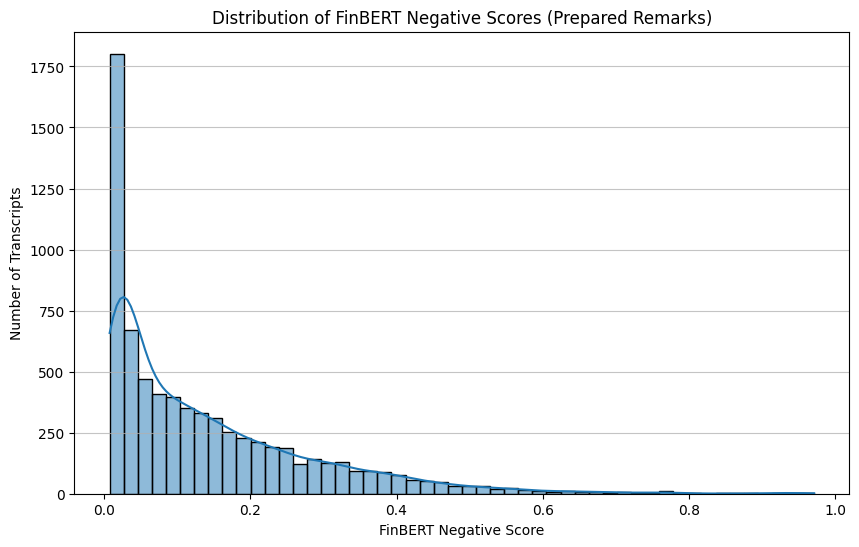

In [ ]:
# Distribution of prepared remarks negative sentiment

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(pdf['prep_finbert_negative'], bins=50, kde=True)
plt.title('Distribution of FinBERT Negative Scores (Prepared Remarks)')
plt.xlabel('FinBERT Negative Score')
plt.ylabel('Number of Transcripts')
plt.grid(axis='y', alpha=0.75)
plt.show()

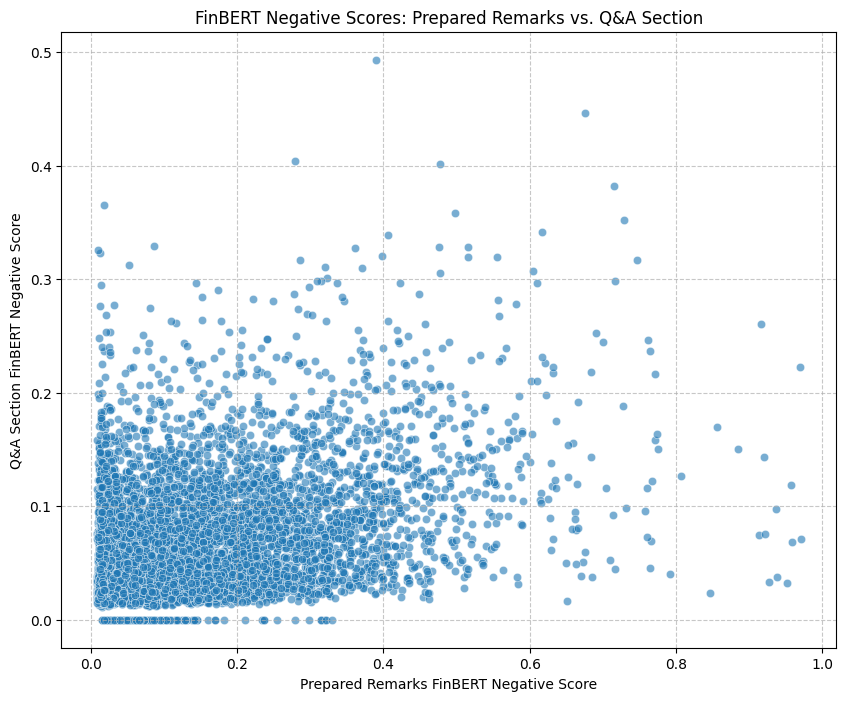

In [ ]:
# Compare prepared remarks and Q&A negative sentiment

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='prep_finbert_negative',
    y='qa_finbert_negative',
    data=pdf,
    alpha=0.6
)
plt.title('FinBERT Negative Scores: Prepared Remarks vs. Q&A Section')
plt.xlabel('Prepared Remarks FinBERT Negative Score')
plt.ylabel('Q&A Section FinBERT Negative Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

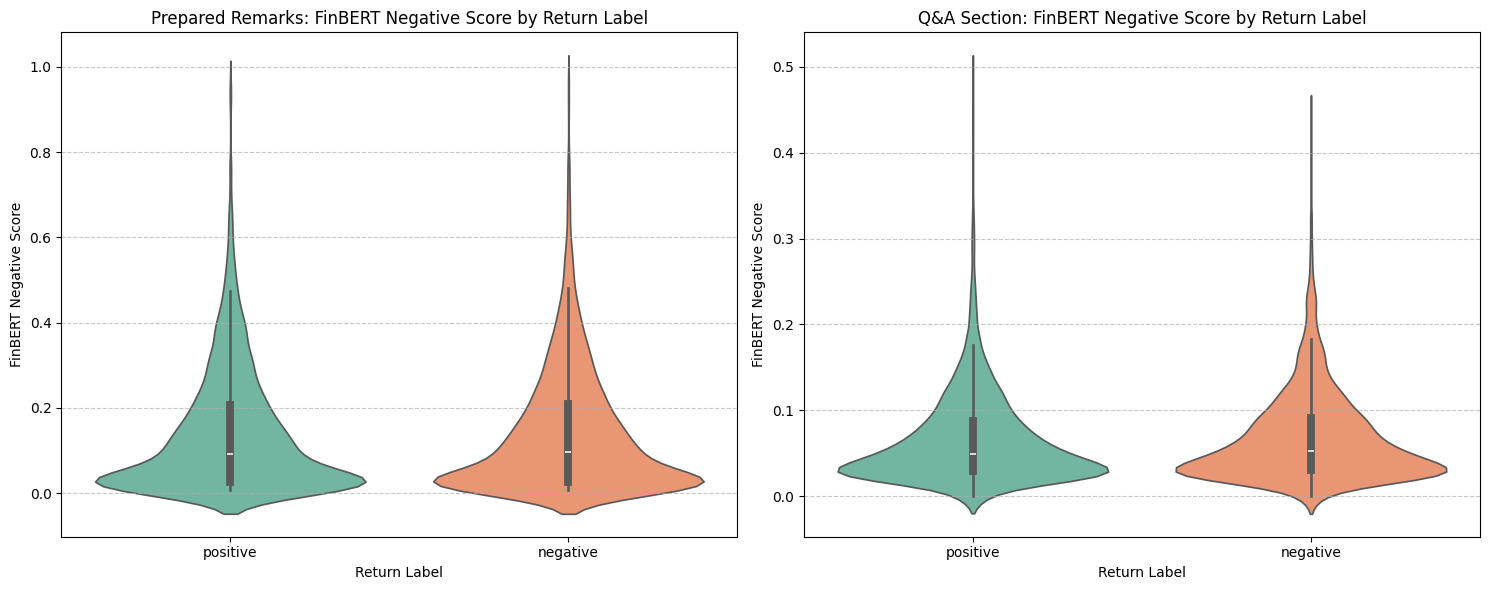

In [ ]:
# FinBERT negative scores by return label

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Prepared Remarks
sns.violinplot(
    x='return_label',
    y='prep_finbert_negative',
    data=pdf,
    hue='return_label',
    legend=False,
    ax=axes[0],
    palette='Set2'
)
axes[0].set_title('Prepared Remarks: FinBERT Negative Score by Return Label')
axes[0].set_xlabel('Return Label')
axes[0].set_ylabel('FinBERT Negative Score')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Q&A Section
sns.violinplot(
    x='return_label',
    y='qa_finbert_negative',
    data=pdf,
    hue='return_label',
    legend=False,
    ax=axes[1],
    palette='Set2'
)
axes[1].set_title('Q&A Section: FinBERT Negative Score by Return Label')
axes[1].set_xlabel('Return Label')
axes[1].set_ylabel('FinBERT Negative Score')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()